# **Deep Learning for Satellite Image Classification** (EuroSAT)
This project uses transfer learning (MobileNetV2) to classify satellite images into 10 land-use categories using the EuroSAT dataset.

In [6]:
!wget https://zenodo.org/record/7711810/files/EuroSAT_RGB.zip

--2026-04-09 09:13:44--  https://zenodo.org/record/7711810/files/EuroSAT_RGB.zip
Resolving zenodo.org (zenodo.org)... 188.185.48.75, 137.138.52.235, 188.184.98.114, ...
Connecting to zenodo.org (zenodo.org)|188.185.48.75|:443... connected.
HTTP request sent, awaiting response... 301 MOVED PERMANENTLY
Location: /records/7711810/files/EuroSAT_RGB.zip [following]
--2026-04-09 09:13:45--  https://zenodo.org/records/7711810/files/EuroSAT_RGB.zip
Reusing existing connection to zenodo.org:443.
HTTP request sent, awaiting response... 200 OK
Length: 94658721 (90M) [application/octet-stream]
Saving to: ‘EuroSAT_RGB.zip’

EuroSAT_RGB.zip     100%[===================>]  90.27M   945KB/s    in 1m 40s  

2026-04-09 09:15:24 (929 KB/s) - ‘EuroSAT_RGB.zip’ saved [94658721/94658721]



# **Dataset Extraction**

In [ ]:
!unzip EuroSAT_RGB.zip

In [8]:
data_dir = "/content/EuroSAT_RGB"

In [9]:
import os
print(os.listdir(data_dir))

['Residential', 'Pasture', 'SeaLake', 'River', 'AnnualCrop', 'Forest', 'Highway', 'PermanentCrop', 'HerbaceousVegetation', 'Industrial']


In [10]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

In [11]:
img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 21600 images belonging to 10 classes.
Found 5400 images belonging to 10 classes.


# **Model Building** (MobileNetV2)

In [12]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [13]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_data.num_classes, activation='softmax')
])

In [14]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [29]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,753,760 (10.50 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 330,518 (1.26 MB)

# **Model Training**

In [15]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 1037s 2s/step - accuracy: 0.7979 - loss: 0.5965 - val_accuracy: 0.8911 - val_loss: 0.3188
Epoch 2/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 1022s 2s/step - accuracy: 0.8664 - loss: 0.3985 - val_accuracy: 0.8978 - val_loss: 0.2957
Epoch 3/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 970s 1s/step - accuracy: 0.8797 - loss: 0.3574 - val_accuracy: 0.9007 - val_loss: 0.2940
Epoch 4/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 975s 1s/step - accuracy: 0.8856 - loss: 0.3290 - val_accuracy: 0.9059 - val_loss: 0.2745
Epoch 5/5
675/675 ━━━━━━━━━━━━━━━━━━━━ 972s 1s/step - accuracy: 0.8933 - loss: 0.3071 - val_accuracy: 0.9094 - val_loss: 0.2603


# **Evaluation** (Accuracy & Loss)

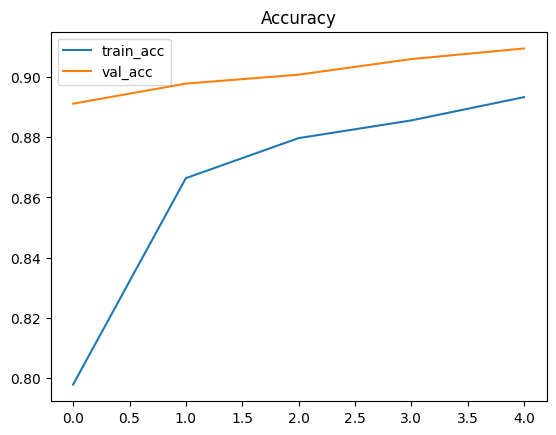

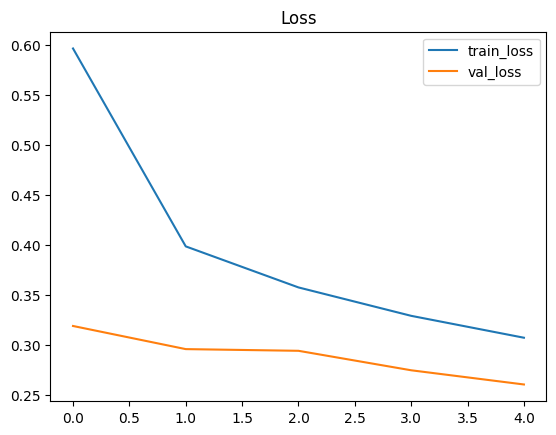

In [19]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss")
plt.show()

169/169 ━━━━━━━━━━━━━━━━━━━━ 204s 1s/step


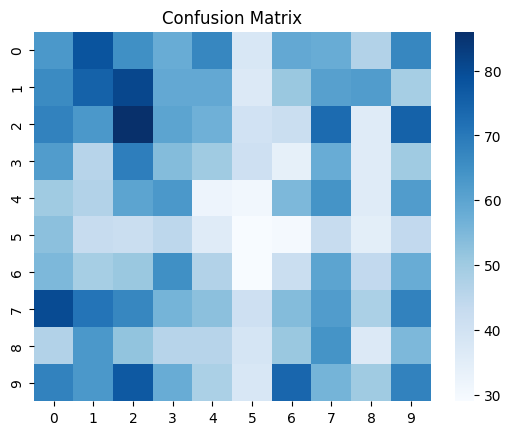

In [20]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(val_data)
y_pred_classes = y_pred.argmax(axis=1)

cm = confusion_matrix(val_data.classes, y_pred_classes)

sns.heatmap(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# **Predictions and Results**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step


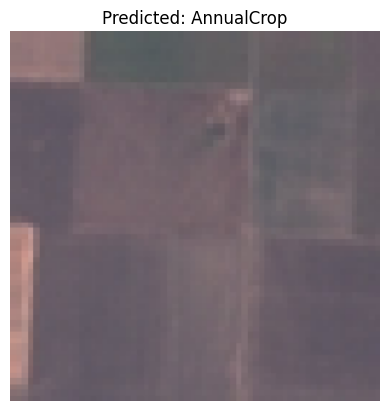

Confidence: 0.9271017


In [18]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Load image
img_path = val_data.filepaths[0]

img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)
class_names = list(train_data.class_indices.keys())

predicted_class = class_names[np.argmax(prediction)]

# Show image
plt.imshow(img)
plt.title(f"Predicted: {predicted_class}")
plt.axis('off')
plt.show()
confidence = np.max(prediction)
print("Confidence:", confidence)

In [31]:
import numpy as np
print("Top 3 Predictions:")

top3_idx = np.argsort(prediction[0])[-3:][::-1]

for i in top3_idx:
    print(f"{class_names[i]}: {prediction[0][i]*100:.2f}%")

Top 3 Predictions:
AnnualCrop: 92.71%
Pasture: 5.64%
PermanentCrop: 1.39%


In [28]:
import matplotlib.pyplot as plt

for i in range(5):
    img_path = val_data.filepaths[i]
    true_label = val_data.classes[i]

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)
    pred_label = np.argmax(pred)

    if pred_label != true_label:
        plt.imshow(img)
        plt.title(f"True: {class_names[true_label]}, Pred: {class_names[pred_label]}")
        plt.axis('off')
        plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 152ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
